# Exploratory Data Analysis

Three datasets:
1. **News Category Dataset** (HuffPost, ~210k articles) — Kaggle: `rmisra/news-category-dataset`
2. **Million Headlines** (ABC Australia, ~1M headlines) — Kaggle: `therohk/million-headlines`
3. **EMDAT** — Global disaster events database (local CSV)

## Setup

Run this cell first. It installs `kagglehub` if needed and imports all libraries.

In [49]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg in ["kagglehub", "pandas", "matplotlib", "seaborn", "openpyxl"]:
    install(pkg)

import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
print("All libraries loaded.")


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


All libraries loaded.


---
## Dataset 1: News Category Dataset (HuffPost)

Filtered to 8 categories: U.S. NEWS, POLITICS, WEIRD NEWS, ENVIRONMENT, EDUCATION, SCIENCE, MEDIA, IMPACT  
Date range: 2012–2021 | Columns kept: `headline`, `publish_date` (YYYYMMDD integer)

In [50]:
# Download dataset — first run may take a minute
path1 = kagglehub.dataset_download("rmisra/news-category-dataset")
print("Downloaded to:", path1)

jsonl_file = [f for f in os.listdir(path1) if f.endswith(".json")][0]
with open(os.path.join(path1, jsonl_file), "r", encoding="utf-8") as f:
    news_raw = pd.DataFrame([json.loads(line) for line in f])

print(f"Raw shape: {news_raw.shape}")
news_raw.head(3)

Downloaded to: /Users/javirubio/.cache/kagglehub/datasets/rmisra/news-category-dataset/versions/3
Raw shape: (209527, 6)


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23


In [51]:
news_raw['category'].value_counts()

category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE            1144
LATINO VOICES      1130
CULTURE & ARTS     1074
EDUCATI

In [52]:
CLIMATE_KEYWORDS = [
    "climate change", "global warming", "sea level",
    "climate", "flood", "wildfire", "bushfire", "drought",
    "hurricane", "cyclone", "heatwave", "emissions", "carbon"
]

Climate keyword headline counts by category:
category
POLITICS          626
GREEN             556
ENVIRONMENT       224
WORLD NEWS         84
BUSINESS           75
IMPACT             72
THE WORLDPOST      60
SCIENCE            56
U.S. NEWS          53
MEDIA              33
COMEDY             31
WELLNESS           28
RELIGION           28
WORLDPOST          28
TRAVEL             25
ENTERTAINMENT      22
HOME & LIVING      21
GOOD NEWS          20
HEALTHY LIVING     17
PARENTING          15
CRIME              14
BLACK VOICES       13
QUEER VOICES       11
WEIRD NEWS         11
TECH               11
STYLE & BEAUTY     10
FOOD & DRINK        9
SPORTS              9
LATINO VOICES       8
WEDDINGS            7
PARENTS             7
MONEY               7
ARTS                7
EDUCATION           6
ARTS & CULTURE      6
TASTE               5
COLLEGE             2
CULTURE & ARTS      2
WOMEN               2
FIFTY               2
DIVORCE             1
Name: count, dtype: int64


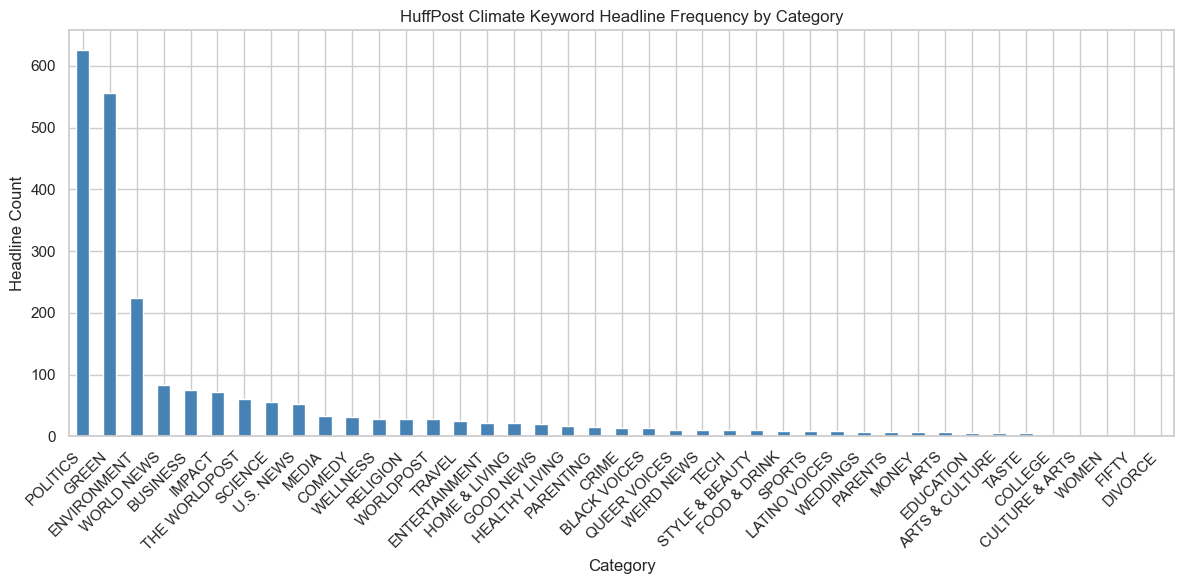

In [53]:
headline_lower = news_raw["headline"].str.lower().fillna("")

climate_mask = headline_lower.apply(
    lambda text: any(kw in text for kw in CLIMATE_KEYWORDS)
)

climate_by_category = (
    news_raw.loc[climate_mask, "category"]
    .value_counts()
    .sort_values(ascending=False)
)

print("Climate keyword headline counts by category:")
print(climate_by_category)

plt.figure(figsize=(12, 6))
climate_by_category.plot(kind="bar", color="steelblue")
plt.title("HuffPost Climate Keyword Headline Frequency by Category")
plt.xlabel("Category")
plt.ylabel("Headline Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [54]:
# Top 10 categories by climate keyword frequency
top_10_climate = climate_by_category.head(10)
print("Top 10 categories by climate keyword mentions:")
print(top_10_climate)

Top 10 categories by climate keyword mentions:
category
POLITICS         626
GREEN            556
ENVIRONMENT      224
WORLD NEWS        84
BUSINESS          75
IMPACT            72
THE WORLDPOST     60
SCIENCE           56
U.S. NEWS         53
MEDIA             33
Name: count, dtype: int64


In [55]:
KEEP_CATS = ["U.S. NEWS", "POLITICS", "WORLD NEWS", "ENVIRONMENT",'GREEN',
             "BUSINESS", "SCIENCE", "MEDIA", "IMPACT", "THE WORLDPOST"]

# Show category counts before dropping the column
print("Articles per kept category (before date filter):")
print(news_raw[news_raw["category"].isin(KEEP_CATS)]["category"].value_counts())

# Filter to selected categories, keep only headline + date
news_usa = (news_raw[news_raw["category"].isin(KEEP_CATS)]
        [["headline", "date"]]
        .copy())

# Parse date, filter to 2012–2021
news_usa["date"] = pd.to_datetime(news_usa["date"], errors="coerce")
news_usa = news_usa[(news_usa["date"].dt.year >= 2012) & (news_usa["date"].dt.year <= 2021)]

# Rename and convert to YYYYMMDD integer (same format as ABC Australia, no dashes)
news_usa = news_usa.rename(columns={"date": "publish_date"})
news_usa["publish_date"] = news_usa["publish_date"].dt.strftime("%Y%m%d").astype(int)

# Drop duplicates and reset index
news_usa = news_usa.drop_duplicates().reset_index(drop=True)

print(f"\nShape after filtering: {news_usa.shape}")
print(f"Date range: {news_usa['publish_date'].min()} → {news_usa['publish_date'].max()}")
news_usa.head(5)

Articles per kept category (before date filter):
category
POLITICS         35602
BUSINESS          5992
THE WORLDPOST     3664
IMPACT            3484
WORLD NEWS        3299
MEDIA             2944
GREEN             2622
SCIENCE           2206
ENVIRONMENT       1444
U.S. NEWS         1377
Name: count, dtype: int64

Shape after filtering: (61704, 2)
Date range: 20120128 → 20211231


,headline,publish_date
0,Ghislaine Maxwell Verdict Bodes Ill For Prince...,20211231
1,'A Hell Of A Year': GOP Anticipating A Triumph...,20211231
2,Navy Objects To Recommendation It Drain Hawaii...,20211230
3,Zoo Tiger Shot And Killed After Biting Man Who...,20211230
4,Politicians Pay Tribute To Former Senate Leade...,20211229


In [56]:
print("=== Data Types & Non-Null Counts ===")
news_usa.info()

print("\n=== Missing Values ===")
print(news_usa.isnull().sum())

print("\n=== Duplicate Rows ===")
print(news_usa.duplicated().sum())

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61704 entries, 0 to 61703
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   headline      61704 non-null  object
 1   publish_date  61704 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 964.3+ KB

=== Missing Values ===
headline        0
publish_date    0
dtype: int64

=== Duplicate Rows ===
0


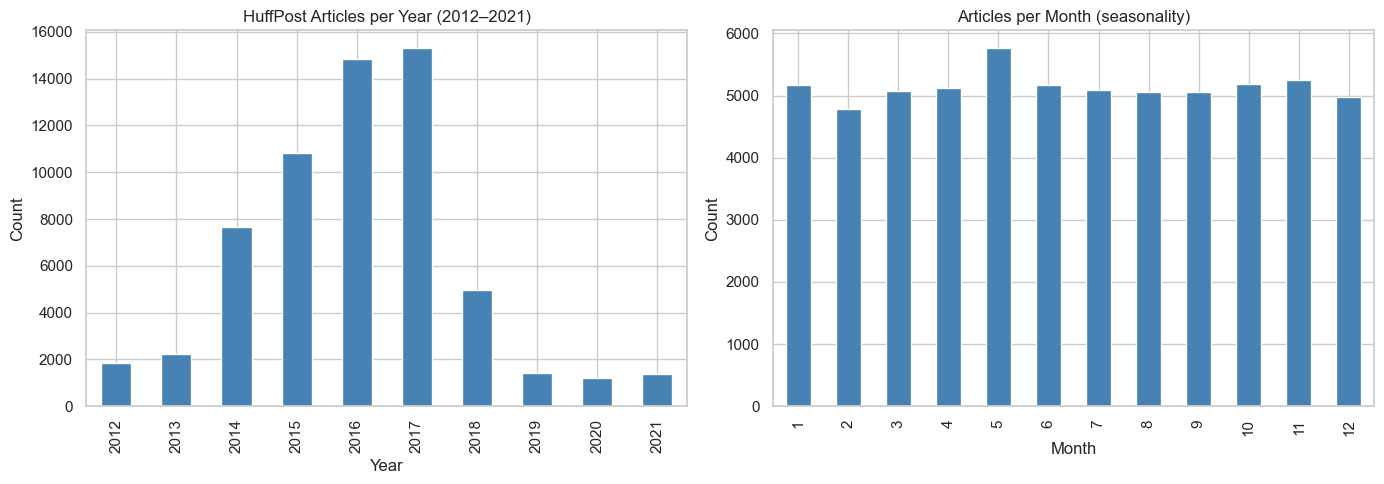

In [57]:
# Convert publish_date back to datetime just for plotting
news_usa_plot = news_usa.copy()
news_usa_plot["date_dt"] = pd.to_datetime(news_usa_plot["publish_date"].astype(str), format="%Y%m%d")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Articles per year
news_usa_plot["date_dt"].dt.year.value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue"
)
axes[0].set_title("HuffPost Articles per Year (2012–2021)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")

# Articles per month (seasonality)
news_usa_plot["date_dt"].dt.month.value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="steelblue"
)
axes[1].set_title("Articles per Month (seasonality)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

count    61704.000000
mean        10.002415
std          2.881326
min          0.000000
25%          8.000000
50%         10.000000
75%         12.000000
max         29.000000
Name: headline_len, dtype: float64


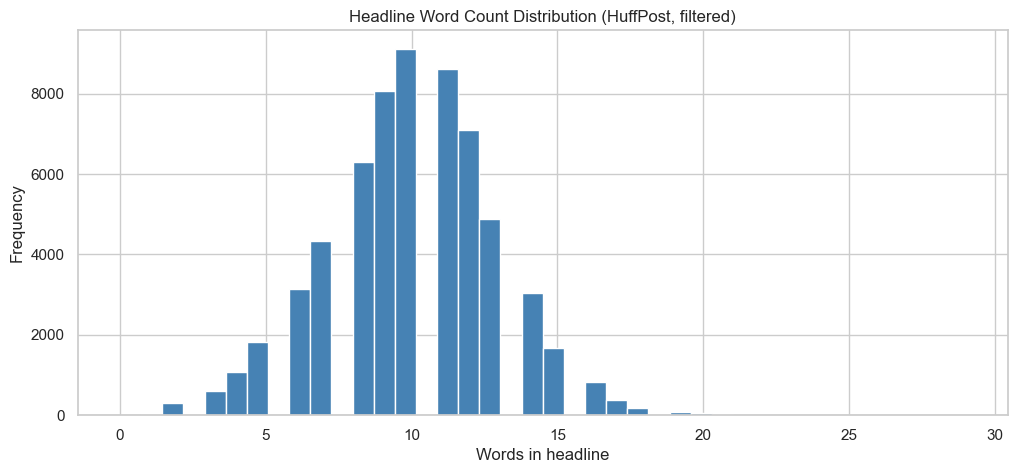

In [58]:
news_usa["headline_len"] = news_usa["headline"].str.split().str.len()
print(news_usa["headline_len"].describe())

news_usa["headline_len"].plot(kind="hist", bins=40, color="steelblue", edgecolor="white")
plt.title("Headline Word Count Distribution (HuffPost, filtered)")
plt.xlabel("Words in headline")
plt.ylabel("Frequency")
plt.show()

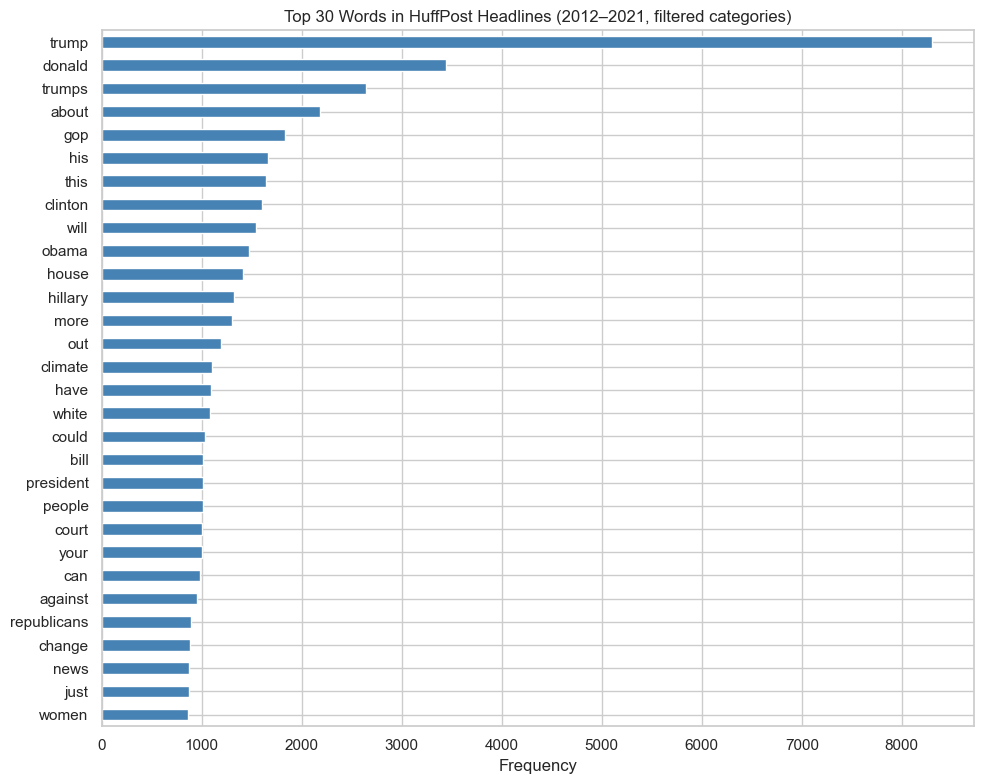

In [59]:
from collections import Counter

STOPWORDS = {"the", "a", "to", "of", "in", "and", "for", "on", "is", "at",
             "by", "as", "an", "with", "says", "over", "be", "up", "was",
             "new", "after", "from", "into", "its", "it", "that", "are",
             "but", "not", "has", "how", "who", "what", "why", "you"}

all_words = (
    news_usa["headline"]
    .str.lower()
    .str.replace(r"[^a-z\s]", "", regex=True)
    .str.split()
    .explode()
    .dropna()
)
word_counts = Counter(w for w in all_words if w not in STOPWORDS and len(w) > 2)

top_words = pd.Series(dict(word_counts.most_common(30)))
top_words.plot(kind="barh", figsize=(10, 8), color="steelblue")
plt.title("Top 30 Words in HuffPost Headlines (2012–2021, filtered categories)")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

=== Keyword counts in HuffPost headlines ===
climate           1112
climate change     583
hurricane          258
flood              136
wildfire           110
carbon              73
drought             68
emissions           55
global warming      47
cyclone             12
sea level           11
heatwave             5
bushfire             2


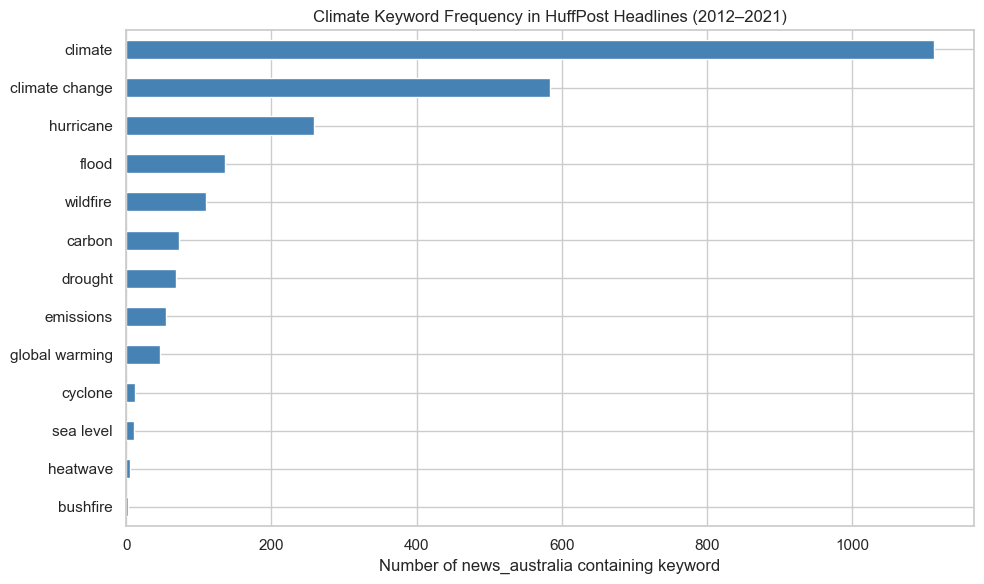

In [60]:
CLIMATE_KEYWORDS = [
    "climate change", "global warming", "sea level",
    "climate", "flood", "wildfire", "bushfire", "drought",
    "hurricane", "cyclone", "heatwave", "emissions", "carbon"
]

headline_lower = news_usa["headline"].str.lower()

keyword_counts = {
    kw: headline_lower.str.contains(kw, regex=False).sum()
    for kw in CLIMATE_KEYWORDS
}

kw_series = pd.Series(keyword_counts).sort_values(ascending=True)
print("=== Keyword counts in HuffPost headlines ===")
print(kw_series.sort_values(ascending=False).to_string())

kw_series.plot(kind="barh", figsize=(10, 6), color="steelblue")
plt.title("Climate Keyword Frequency in HuffPost Headlines (2012–2021)")
plt.xlabel("Number of news_australia containing keyword")
plt.tight_layout()
plt.show()

In [61]:
headline_lower = news_usa["headline"].str.lower()
climate_mask = headline_lower.apply(lambda text: any(kw in text for kw in CLIMATE_KEYWORDS))
num_climate_headlines = climate_mask.sum()
print(f"Number of headlines in the filtered dataset containing at least one climate keyword: {num_climate_headlines}")

Number of headlines in the filtered dataset containing at least one climate keyword: 1811


---
## Dataset 2: Million Headlines (ABC Australia)

Filtered to 2012–2021 | Columns: `publish_date` (datetime), `headline_text`

In [62]:
# Download dataset
path2 = kagglehub.dataset_download("therohk/million-headlines")
print("Downloaded to:", path2)

csv_file = [f for f in os.listdir(path2) if f.endswith(".csv")][0]
news_australia = pd.read_csv(os.path.join(path2, csv_file))

print(f"Shape: {news_australia.shape}")
news_australia.head(3)

Downloaded to: /Users/javirubio/.cache/kagglehub/datasets/therohk/million-headlines/versions/5
Shape: (1244184, 2)


,publish_date,headline_text
0,20030219,aba decides against community broadcasting lic...
1,20030219,act fire witnesses must be aware of defamation
2,20030219,a g calls for infrastructure protection summit


In [63]:
print("=== Missing Values (raw) ===")
print(news_australia.isnull().sum())

print(f"\n=== Duplicates (raw): {news_australia.duplicated().sum()} ===")

# Parse date (format: YYYYMMDD integer)
news_australia["publish_date"] = pd.to_datetime(
    news_australia["publish_date"].astype(str), format="%Y%m%d", errors="coerce"
)

# Filter to 2012–2021
news_australia = (news_australia[
    (news_australia["publish_date"].dt.year >= 2012) &
    (news_australia["publish_date"].dt.year <= 2021)
].drop_duplicates().reset_index(drop=True))

print(f"\nShape after filtering to 2012–2021: {news_australia.shape}")
print(f"Date range: {news_australia['publish_date'].min()} → {news_australia['publish_date'].max()}")
news_australia.head(3)

=== Missing Values (raw) ===
publish_date     0
headline_text    0
dtype: int64

=== Duplicates (raw): 2 ===

Shape after filtering to 2012–2021: (581168, 2)
Date range: 2012-01-01 00:00:00 → 2021-12-31 00:00:00


,publish_date,headline_text
0,2012-01-01,abc entertainment
1,2012-01-01,abc sport
2,2012-01-01,abc weather


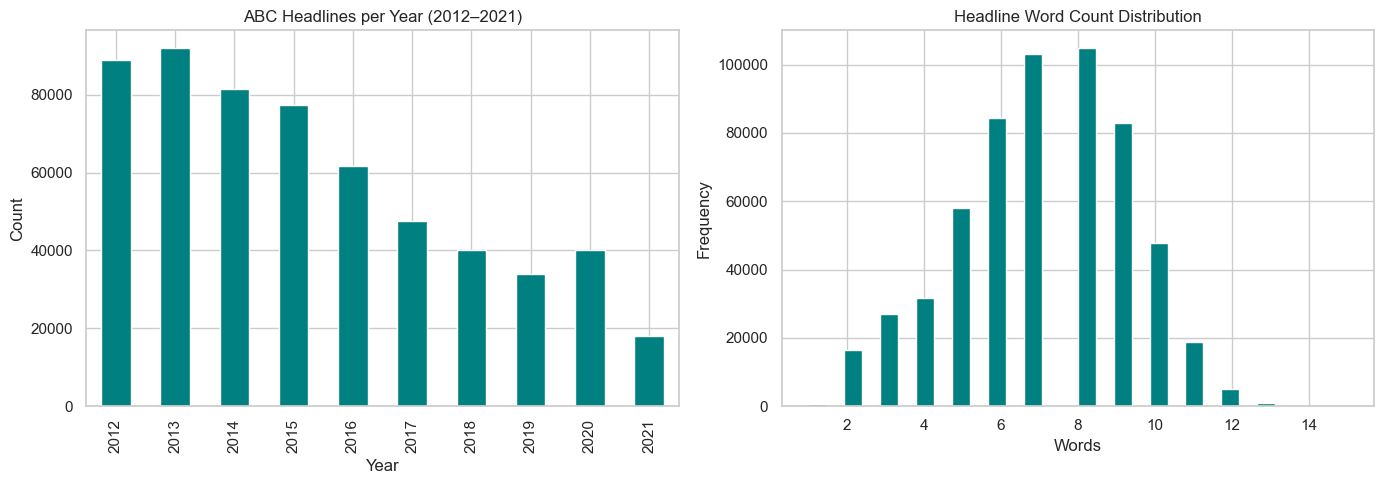

count    581168.000000
mean          7.051195
std           2.192927
min           1.000000
25%           6.000000
50%           7.000000
75%           9.000000
max          15.000000
Name: word_count, dtype: float64


In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Headlines per year
news_australia["publish_date"].dt.year.value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="teal"
)
axes[0].set_title("ABC Headlines per Year (2012–2021)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")

# Headline word count distribution
news_australia["word_count"] = news_australia["headline_text"].str.split().str.len()
news_australia["word_count"].plot(kind="hist", bins=30, ax=axes[1], color="teal", edgecolor="white")
axes[1].set_title("Headline Word Count Distribution")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(news_australia["word_count"].describe())

=== 20 random headlines ===
remote ninuku arts centre fosters its next gene...
prediction for strong house price growth in tas...
support group research highlights terrible impa...
spains children allowed outside coronavirus res...
health sector faces full blown crisis jack snel...
hospitals apply for end to nurses' industrial a...
tropfest cancelled over terrible mismanagement ...
broken hill councillors knock back proposal to ...
leveson inquest hears recording of friend confr...
                 parts of nsw under total fire ban
unisa and adelaide university decide against me...
fax machines being kept on life support by act ...
                               live myefo reaction
                                 hospital contract
  council urged to get aboard inland rail alliance
               amp shares tumble to one month lows
investigation continuin in to possible north co...
 sia sends message for adelaide contemporary music
                 state opposition joins a labor mp
   

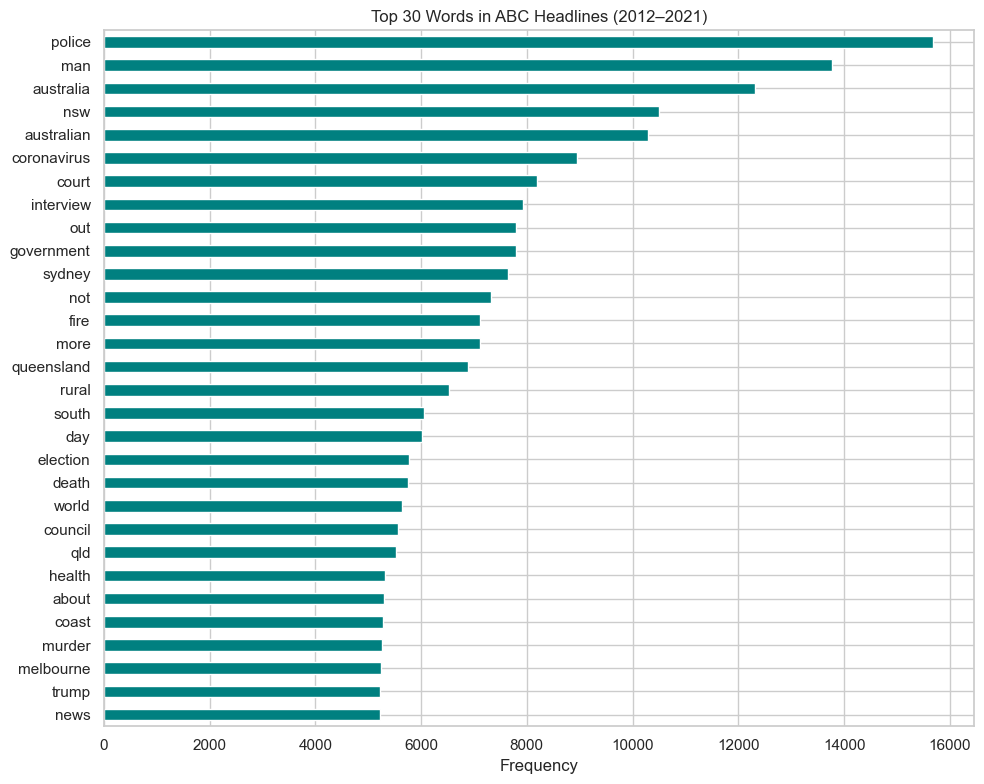

In [65]:
# Sample headlines to get a feel for the content
print("=== 20 random headlines ===")
print(news_australia["headline_text"].sample(20, random_state=42).to_string(index=False))

# Most common words (excluding very common stop words)
from collections import Counter

STOPWORDS = {"the", "a", "to", "of", "in", "and", "for", "on", "is", "at",
             "by", "as", "an", "with", "says", "over", "be", "up", "was",
             "new", "aus", "after", "from", "into", "its", "it", "that"}

all_words = (
    news_australia["headline_text"]
    .str.lower()
    .str.split()
    .explode()
)
word_counts = Counter(w for w in all_words if w not in STOPWORDS and len(w) > 2)

top_words = pd.Series(dict(word_counts.most_common(30)))
top_words.plot(kind="barh", figsize=(10, 8), color="teal")
plt.title("Top 30 Words in ABC Headlines (2012–2021)")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

=== Keyword counts in ABC headlines ===
flood             3986
bushfire          3294
drought           2301
climate           2098
cyclone           1707
climate change    1142
carbon            1051
heatwave           452
hurricane          426
emissions          378
wildfire           153
sea level           80
global warming      50


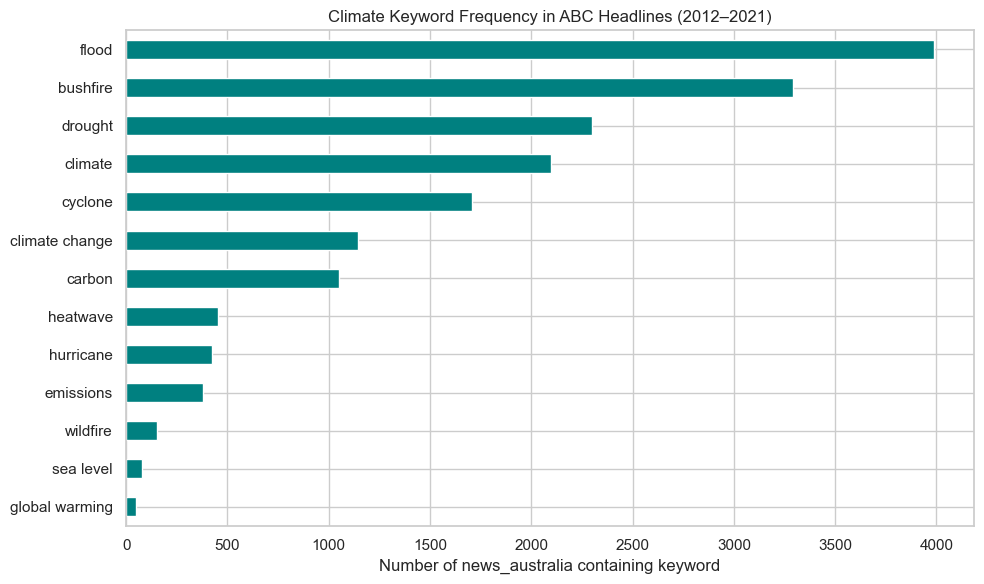

In [66]:
CLIMATE_KEYWORDS = [
    "climate change", "global warming", "sea level",
    "climate", "flood", "wildfire", "bushfire", "drought",
    "hurricane", "cyclone", "heatwave", "emissions", "carbon"
]

headline_lower = news_australia["headline_text"].str.lower()

keyword_counts = {
    kw: headline_lower.str.contains(kw, regex=False).sum()
    for kw in CLIMATE_KEYWORDS
}

kw_series = pd.Series(keyword_counts).sort_values(ascending=True)
print("=== Keyword counts in ABC headlines ===")
print(kw_series.sort_values(ascending=False).to_string())

kw_series.plot(kind="barh", figsize=(10, 6), color="teal")
plt.title("Climate Keyword Frequency in ABC Headlines (2012–2021)")
plt.xlabel("Number of news_australia containing keyword")
plt.tight_layout()
plt.show()

In [67]:
headline_lower = news_australia["headline_text"].str.lower()
climate_mask = headline_lower.apply(lambda text: any(kw in text for kw in CLIMATE_KEYWORDS))
num_climate_headlines_abc = climate_mask.sum()
print(f"Number of headlines in ABC dataset containing at least one climate keyword: {num_climate_headlines_abc}")

Number of headlines in ABC dataset containing at least one climate keyword: 15534


---
## Dataset 3: EMDAT — Natural Disaster Events

Filtered to **Natural disasters only** (Technological removed).  
Local file: `data/EMDAT.csv` (semicolon-delimited)

In [68]:
import os

# Set working directory to the project root
notebook_dir = os.path.dirname(os.path.abspath("eda.ipynb"))
os.chdir(notebook_dir)

emdat_path = os.path.join(notebook_dir, "data", "EMDAT.csv")
emdat_raw = pd.read_csv(emdat_path, sep=";", encoding="latin-1", low_memory=False)
print(f"Raw shape: {emdat_raw.shape}")
print("Disaster Group counts:")
print(emdat_raw["Disaster Group"].value_counts())

# Keep only Natural disasters
emdat = emdat_raw[emdat_raw["Disaster Group"] == "Natural"].copy().reset_index(drop=True)
print(f"\nShape after filtering to Natural only: {emdat.shape}")
emdat.head(3)

Raw shape: (331, 47)
Disaster Group counts:
Disaster Group
Natural          300
Technological     31
Name: count, dtype: int64

Shape after filtering to Natural only: (300, 47)


,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,2018-0111-USA,No,nat-met-sto-bli,Natural,Meteorological,Storm,Blizzard/Winter storm,NaN,NaN,USA,...,NaN,1400000.0,1748916.0,2300000.0,2873219.0,"80,04959626","[{""adm1_code"":3220,""adm1_name"":""Connecticut""},...","[{""gid_1"":""USA.21_1"",""migration_date"":""2025-12...",2018-04-13,2025-12-20
1,2016-0493-USA,No,nat-geo-ear-gro,Natural,Geophysical,Earthquake,Ground movement,USGS:us100075y8,NaN,USA,...,NaN,NaN,NaN,20000.0,26140.0,"76,5112162","[{""adm1_code"":3250,""adm1_name"":""Oklahoma""}]","[{""gid_1"":""USA.37_1"",""migration_date"":""2025-12...",2016-12-15,2026-01-25
2,2019-0306-USA,No,nat-geo-ear-gro,Natural,Geophysical,Earthquake,Ground movement,GLIDE:EQ-2019-000077|USGS:ci38457511,NaN,USA,...,NaN,50000.0,61349.0,200000.0,245398.0,"81,50030941","[{""adm2_code"":28879,""adm2_name"":""Kern""}]","[{""gid_2"":""USA.5.15_1"",""migration_date"":""2025-...",2019-07-09,2026-01-25


In [69]:
print("=== Columns ===")
print(list(emdat.columns))

print("\n=== Data Types ===")
emdat.info()

print("\n=== Missing Values (%) ===")
missing = (emdat.isnull().sum() / len(emdat) * 100).sort_values(ascending=False)
print(missing[missing > 0].round(1))

=== Columns ===
['DisNo.', 'Historic', 'Classification Key', 'Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype', 'External IDs', 'Event Name', 'ISO', 'Country', 'Subregion', 'Region', 'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal', 'Declaration', "AID Contribution ('000 US$)", 'Magnitude', 'Magnitude Scale', 'Latitude', 'Longitude', 'River Basin', 'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day', 'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected', "Reconstruction Costs ('000 US$)", "Reconstruction Costs, Adjusted ('000 US$)", "Insured Damage ('000 US$)", "Insured Damage, Adjusted ('000 US$)", "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)", 'CPI', 'Admin Units', 'GADM Admin Units', 'Entry Date', 'Last Update']

=== Data Types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 47 columns):
 #   Column                       

In [70]:
# Fix numeric columns that may have commas as decimal separators
for col in ["Total Deaths", "No. Affected", "Total Affected",
            "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)"]:
    if col in emdat.columns:
        emdat[col] = (
            emdat[col].astype(str)
            .str.replace(",", ".", regex=False)
            .str.replace(" ", "", regex=False)
            .pipe(pd.to_numeric, errors="coerce")
        )

print(emdat[["Start Year", "Total Deaths", "Total Affected",
             "Total Damage ('000 US$)"]].describe())

        Start Year  Total Deaths  Total Affected  Total Damage ('000 US$)
count   300.000000    228.000000    1.780000e+02             2.720000e+02
mean   2016.710000     14.842105    4.974206e+05             2.673742e+06
std       3.001544     28.705117    6.370711e+06             8.725898e+06
min    2012.000000      1.000000    1.000000e+00             2.000000e+03
25%    2014.000000      2.000000    1.200000e+02             1.750000e+05
50%    2016.500000      5.000000    5.535000e+02             9.500000e+05
75%    2020.000000     15.000000    3.568500e+03             2.000000e+06
max    2021.000000    235.000000    8.500001e+07             9.500000e+07


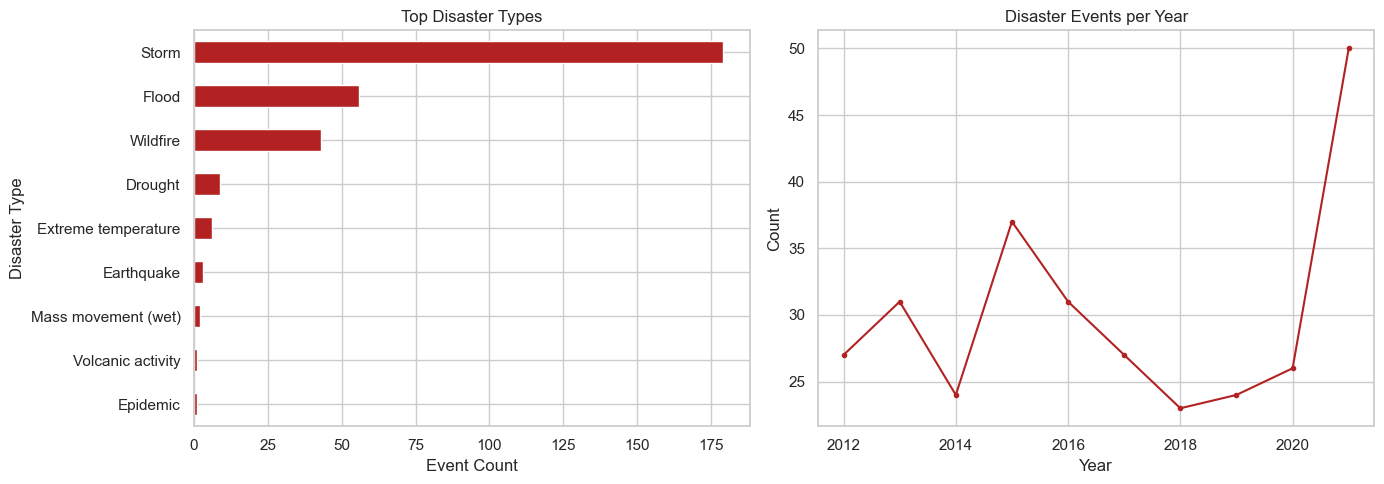

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Disaster type counts
emdat["Disaster Type"].value_counts().head(12).plot(
    kind="barh", ax=axes[0], color="firebrick"
)
axes[0].set_title("Top Disaster Types")
axes[0].set_xlabel("Event Count")
axes[0].invert_yaxis()

# Events per year
emdat["Start Year"].value_counts().sort_index().plot(
    kind="line", ax=axes[1], color="firebrick", marker="o", markersize=3
)
axes[1].set_title("Disaster Events per Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

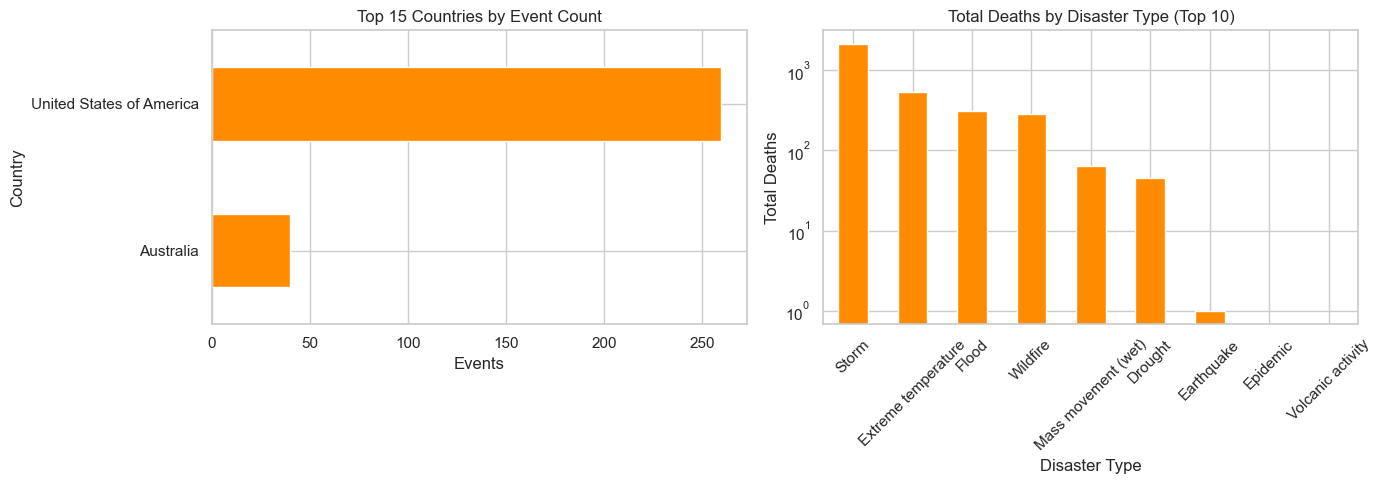

In [72]:
# Top 15 countries by event count
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

emdat["Country"].value_counts().head(15).plot(
    kind="barh", ax=axes[0], color="darkorange"
)
axes[0].set_title("Top 15 Countries by Event Count")
axes[0].set_xlabel("Events")
axes[0].invert_yaxis()

# Deaths by disaster type (sum, log scale)
deaths_by_type = (
    emdat.groupby("Disaster Type")["Total Deaths"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
deaths_by_type.plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Total Deaths by Disaster Type (Top 10)")
axes[1].set_ylabel("Total Deaths")
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()